In [ ]:
#1.1 Сегментация данных по рейтингу

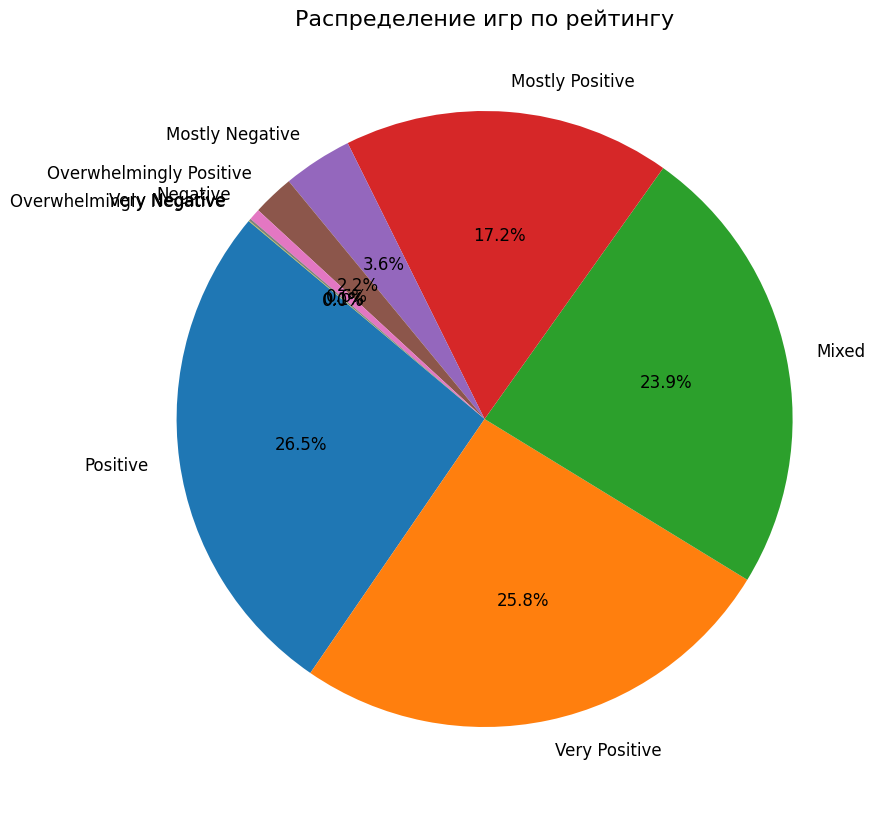

In [ ]:
import matplotlib.pyplot as plt

# Сегментация данных по рейтингу
rating_counts = preprocessed_data['rating'].value_counts()

# Визуализация
plt.figure(figsize=(10, 10))  # Увеличиваем размер графика
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
plt.title("Распределение игр по рейтингу", fontsize=16)
plt.show()



In [ ]:
#1.2. Сегментация по диапазону цены (price_final)

Распределение по ценовым сегментам (price_final):
price_segment
0.02-0.05    14079
0-0.01       11032
0.01-0.02     8580
0.05-0.1      6346
0.1-0.2       1430
0.2-1.0        300
Name: count, dtype: int64


<ipython-input-8-0925daa5cf39>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_segment_counts.index, y=price_segment_counts.values, palette='coolwarm')


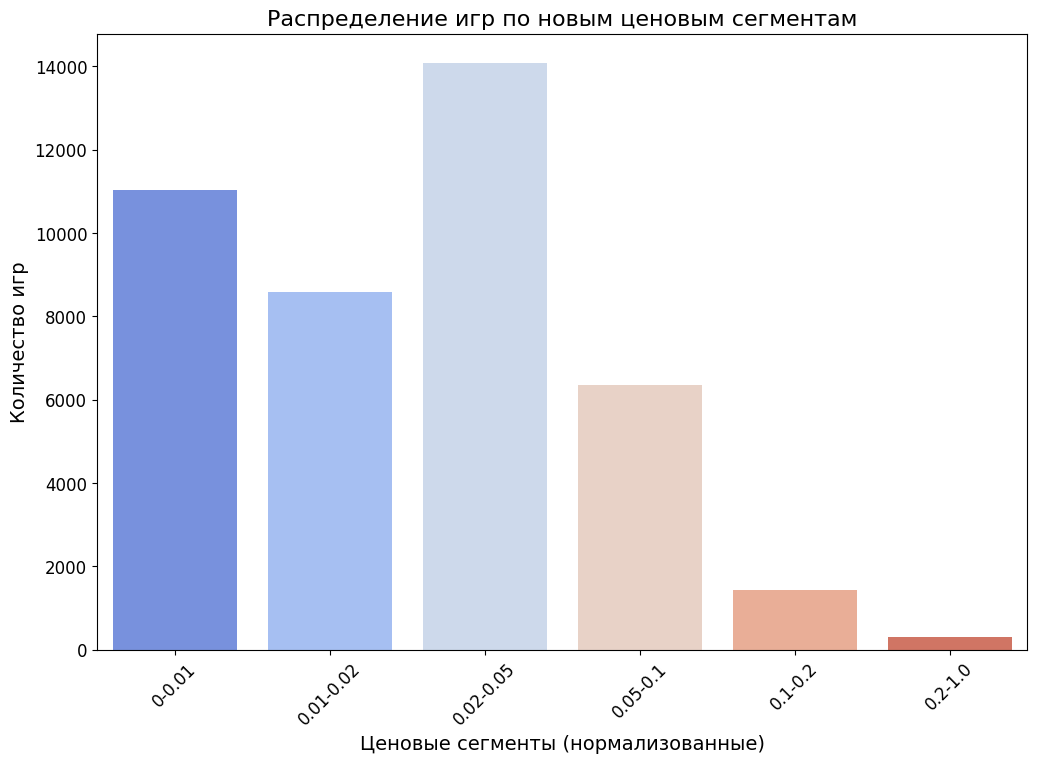

In [ ]:
# Корректировка диапазонов для price_final
price_bins = [0, 0.01, 0.02, 0.05, 0.1, 0.2, 1.0]  # Интервалы на основе распределения
price_labels = ['0-0.01', '0.01-0.02', '0.02-0.05', '0.05-0.1', '0.1-0.2', '0.2-1.0']

# Создание сегментов
preprocessed_data['price_segment'] = pd.cut(preprocessed_data['price_final'], bins=price_bins, labels=price_labels)

# Проверим количество записей в каждом сегменте
price_segment_counts = preprocessed_data['price_segment'].value_counts()
print("Распределение по ценовым сегментам (price_final):")
print(price_segment_counts)

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=price_segment_counts.index, y=price_segment_counts.values, palette='coolwarm')
plt.title("Распределение игр по новым ценовым сегментам", fontsize=16)
plt.xlabel("Ценовые сегменты (нормализованные)", fontsize=14)
plt.ylabel("Количество игр", fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.show()


In [ ]:
# 1.3. Сегментация по времени выпуска (date_release)

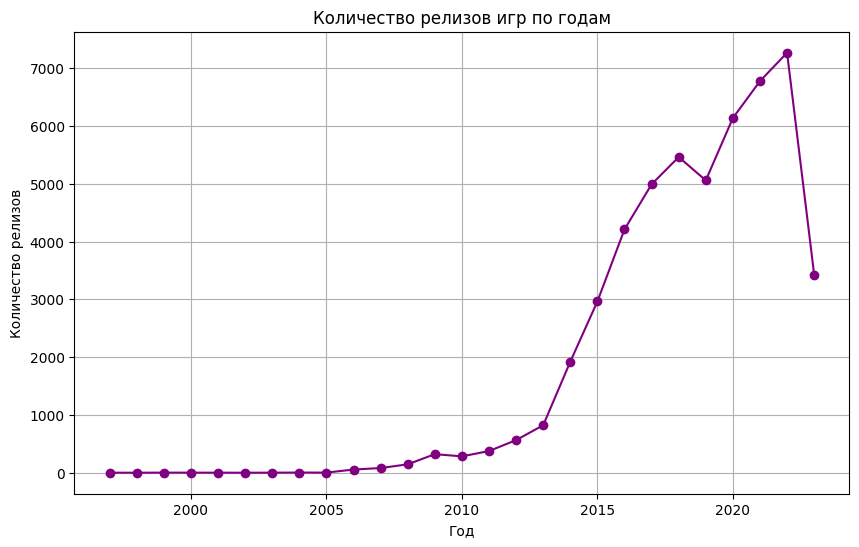

In [ ]:
# Сегментация по годам выпуска
preprocessed_data['release_year'] = pd.to_datetime(preprocessed_data['date_release']).dt.year
release_year_counts = preprocessed_data['release_year'].value_counts().sort_index()

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(release_year_counts.index, release_year_counts.values, marker='o', color='purple')
plt.title("Количество релизов игр по годам")
plt.xlabel("Год")
plt.ylabel("Количество релизов")
plt.grid()
plt.show()


In [ ]:
# 1.4 Сегментация по платформам (win, mac, linux)

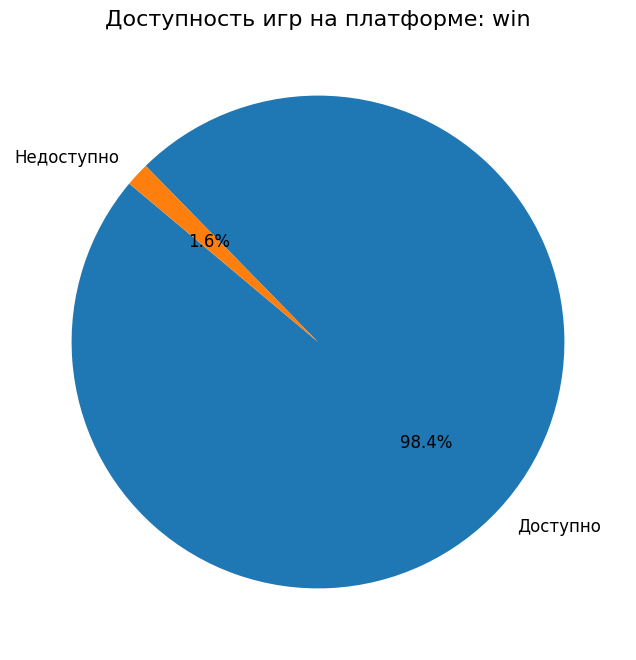

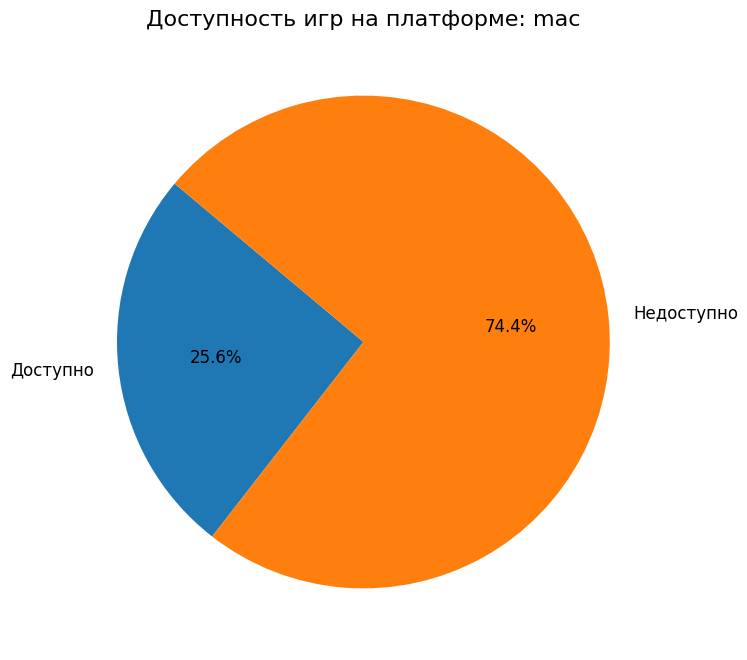

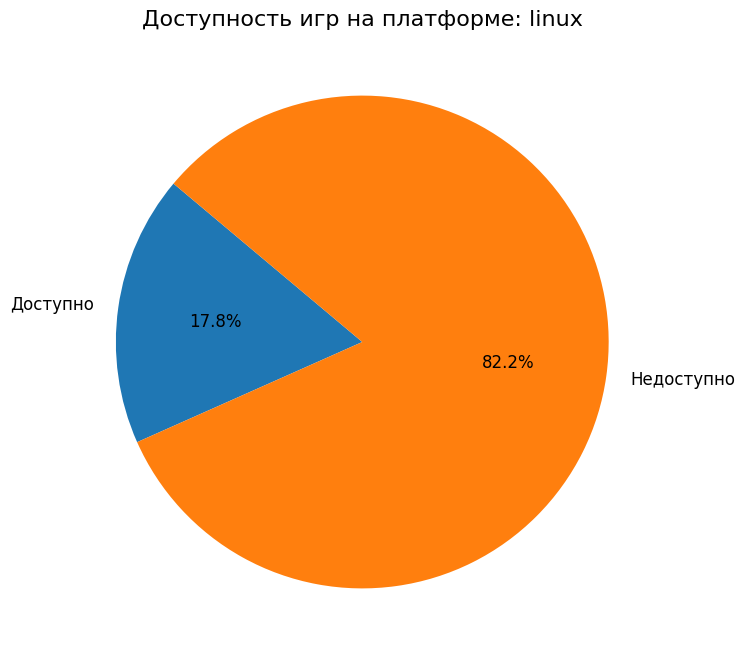

<ipython-input-14-54c371067cc8>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(platform_counts.keys()), y=list(platform_counts.values()), palette='Set2')


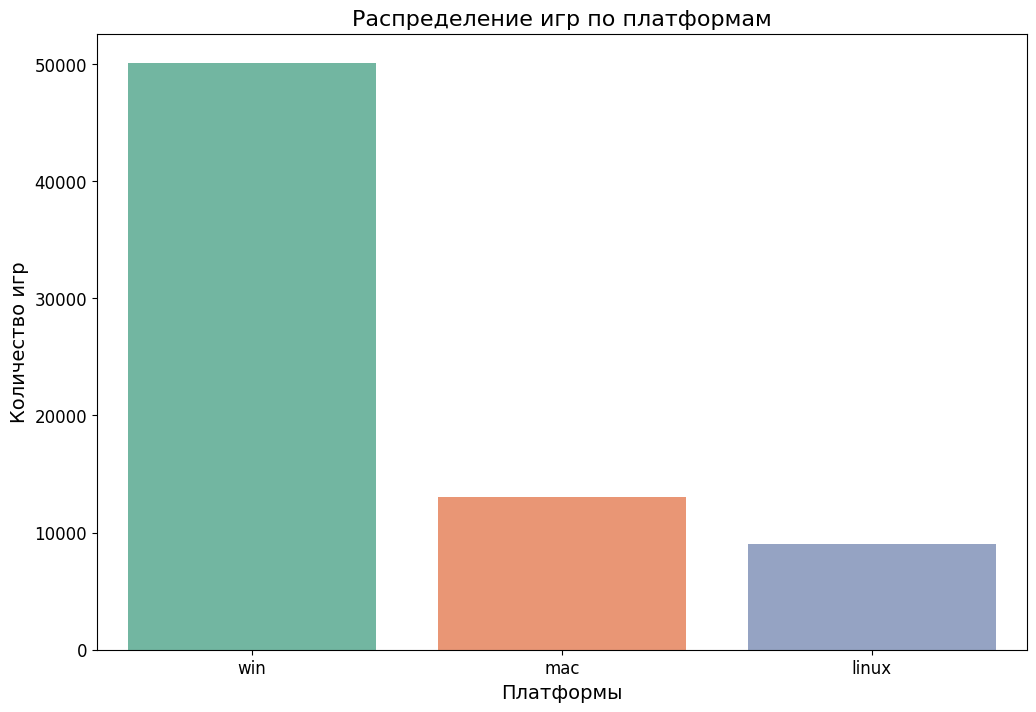

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Определение платформ
platforms = ['win', 'mac', 'linux']  # Убедитесь, что эти столбцы есть в ваших данных

# Подсчёт количества игр для каждой платформы
platform_counts = {platform: preprocessed_data[platform].sum() for platform in platforms}

# Визуализация доступности игр на каждой платформе (круговая диаграмма)
for platform in platforms:
    if platform in preprocessed_data.columns:  # Проверяем, существует ли колонка
        platform_count = preprocessed_data[platform].sum()
        plt.figure(figsize=(8, 8))  # Увеличиваем размер графика
        plt.pie(
            [platform_count, len(preprocessed_data) - platform_count],
            labels=['Доступно', 'Недоступно'],
            autopct='%1.1f%%',
            startangle=140,
            textprops={'fontsize': 12}
        )
        plt.title(f"Доступность игр на платформе: {platform}", fontsize=16)
        plt.show()
    else:
        print(f"Колонка '{platform}' отсутствует в данных.")

# Визуализация распределения игр по платформам (столбчатый график)
plt.figure(figsize=(12, 8))
sns.barplot(x=list(platform_counts.keys()), y=list(platform_counts.values()), palette='Set2')
plt.title("Распределение игр по платформам", fontsize=16)
plt.xlabel("Платформы", fontsize=14)
plt.ylabel("Количество игр", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [ ]:
# Бонус

Топ-20 игр за весь период:
                                  title  user_reviews                   rating
14398  Counter-Strike: Global Offensive      1.000000            Very Positive
47770               PUBG: BATTLEGROUNDS      0.295848                    Mixed
13176                            Dota 2      0.272951            Very Positive
12717                Grand Theft Auto V      0.198028            Very Positive
14535   Tom Clancy's Rainbow Six® Siege      0.132538            Very Positive
47380                   Team Fortress 2      0.131539            Very Positive
13035                          Terraria      0.125880  Overwhelmingly Positive
15363                       Garry's Mod      0.113914  Overwhelmingly Positive
13173                              Rust      0.104965            Very Positive
14376                     Apex Legends™      0.095160            Very Positive
12800         The Witcher® 3: Wild Hunt      0.089192  Overwhelmingly Positive
47791                  Wa

<ipython-input-20-c368ead3ffad>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


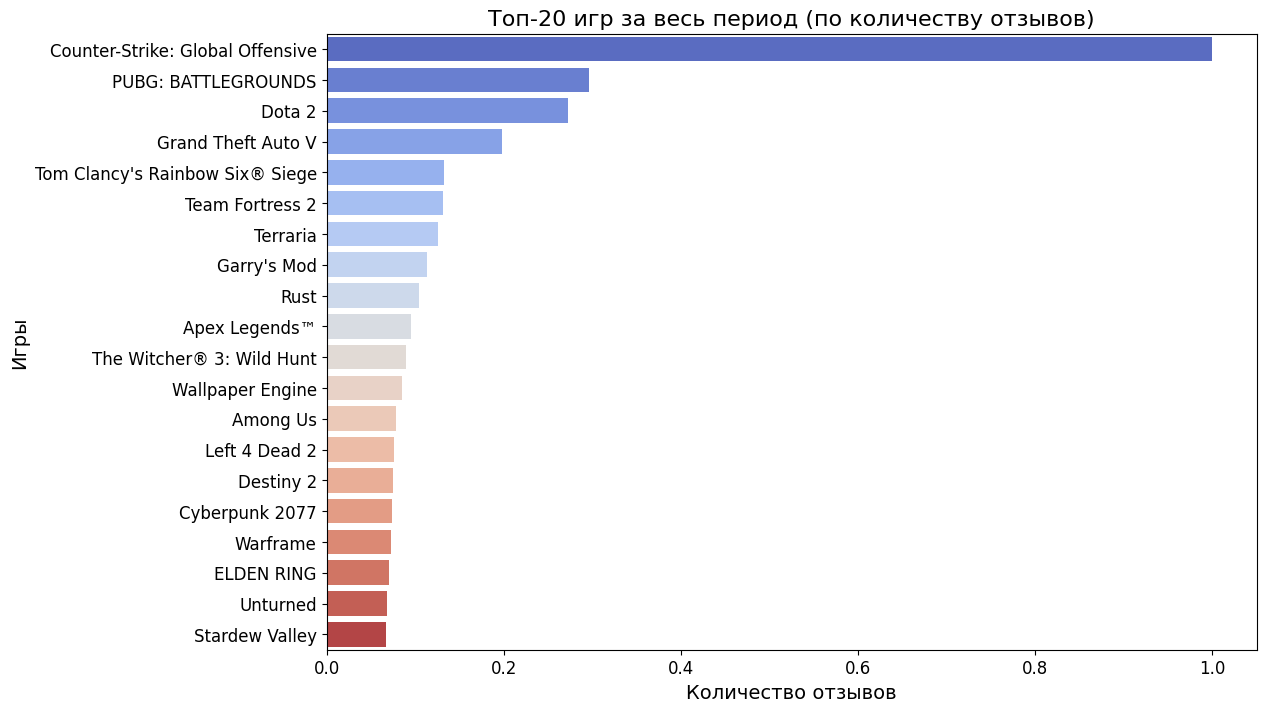

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Получение топ-20 игр по количеству отзывов
top_20_games = preprocessed_data.nlargest(20, 'user_reviews')

# Вывод названий, количества отзывов и рейтинга
print("Топ-20 игр за весь период:")
print(top_20_games[['title', 'user_reviews', 'rating']])

# Визуализация: бар график количества отзывов для топ-20 игр
plt.figure(figsize=(12, 8))
sns.barplot(
    x=top_20_games['user_reviews'],
    y=top_20_games['title'],
    palette='coolwarm',
    orient='h'  # горизонтальный график для удобства
)
plt.title("Топ-20 игр за весь период (по количеству отзывов)", fontsize=16)
plt.xlabel("Количество отзывов", fontsize=14)
plt.ylabel("Игры", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [ ]:
# 2.1 Анализ трендов релизов игр по годам
# Определим, как менялось количество релизов игр в разные годы.

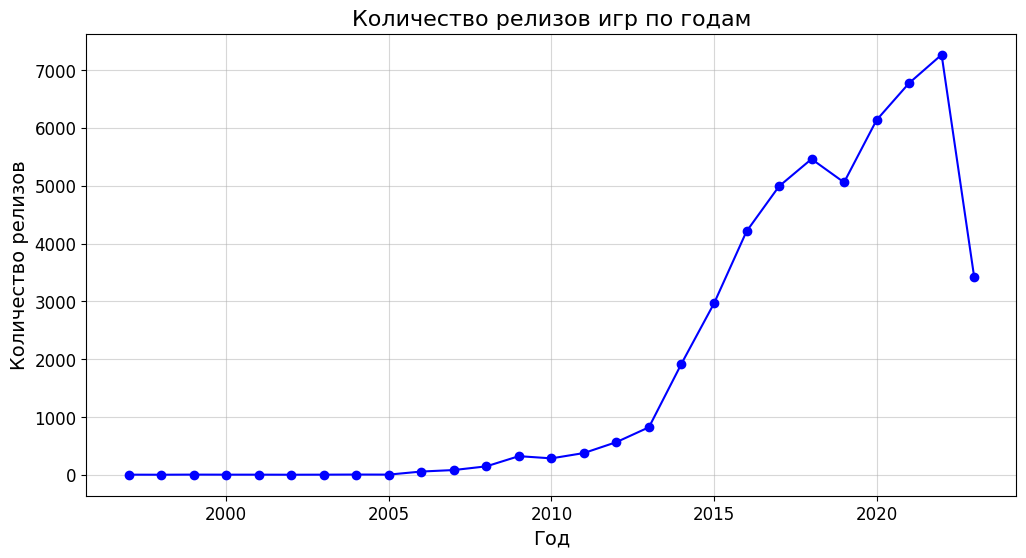

In [ ]:
# Подготовка данных
preprocessed_data['date_release'] = pd.to_datetime(preprocessed_data['date_release'], errors='coerce')
preprocessed_data['release_year'] = preprocessed_data['date_release'].dt.year

# Группировка по годам
release_year_counts = preprocessed_data.groupby('release_year').size()

# Визуализация тренда
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(release_year_counts.index, release_year_counts.values, marker='o', color='blue')
plt.title("Количество релизов игр по годам", fontsize=16)
plt.xlabel("Год", fontsize=14)
plt.ylabel("Количество релизов", fontsize=14)
plt.grid(alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [ ]:
# 2.2. Анализ сезонности релизов игр
# Посмотрим, в какие месяцы чаще всего выпускаются игры.

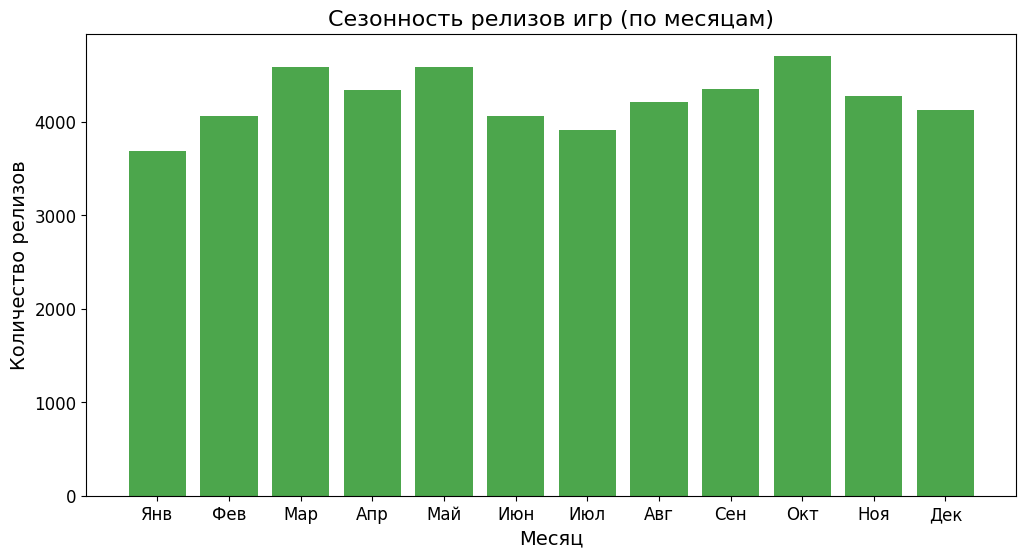

In [ ]:
# Извлечение месяца из даты релиза
preprocessed_data['release_month'] = preprocessed_data['date_release'].dt.month

# Группировка по месяцам
release_month_counts = preprocessed_data.groupby('release_month').size()

# Визуализация сезонности
plt.figure(figsize=(12, 6))
plt.bar(release_month_counts.index, release_month_counts.values, color='green', alpha=0.7)
plt.title("Сезонность релизов игр (по месяцам)", fontsize=16)
plt.xlabel("Месяц", fontsize=14)
plt.ylabel("Количество релизов", fontsize=14)
plt.xticks(range(1, 13), ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'], fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [ ]:
#2.3. Анализ ценовых изменений во времени
#Посмотрим, как изменялись цены на игры со временем, выявляя тренды в price_final.

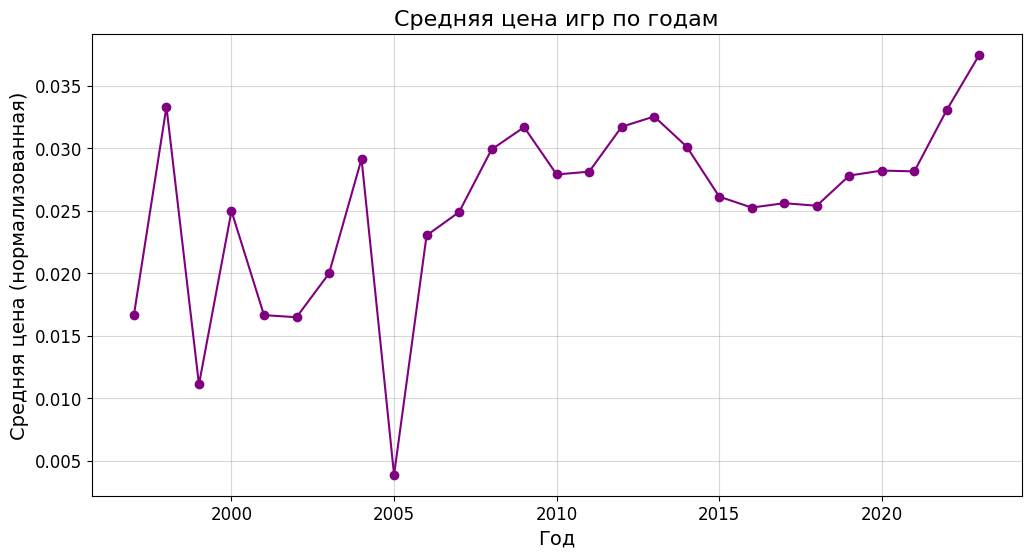

In [ ]:
# Группировка по годам и расчёт средней цены
price_trend = preprocessed_data.groupby('release_year')['price_final'].mean()

# Визуализация ценового тренда
plt.figure(figsize=(12, 6))
plt.plot(price_trend.index, price_trend.values, marker='o', color='purple')
plt.title("Средняя цена игр по годам", fontsize=16)
plt.xlabel("Год", fontsize=14)
plt.ylabel("Средняя цена (нормализованная)", fontsize=14)
plt.grid(alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [ ]:
# Поиск аномалий

In [ ]:
# 3. 1. Графический анализ выбросов

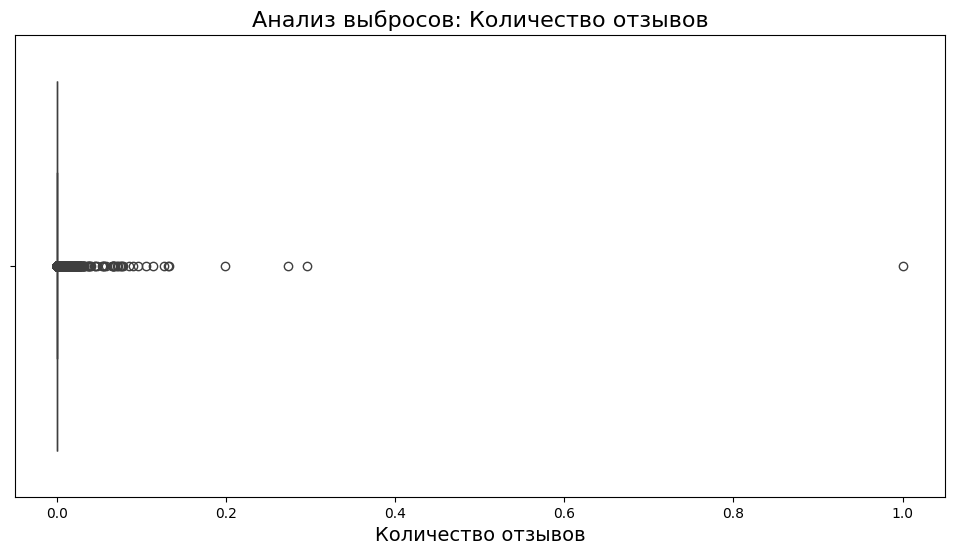

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Пример для анализа количества отзывов
plt.figure(figsize=(12, 6))
sns.boxplot(x=preprocessed_data['user_reviews'])
plt.title("Анализ выбросов: Количество отзывов", fontsize=16)
plt.xlabel("Количество отзывов", fontsize=14)
plt.show()


In [ ]:
# 3.2. Метод межквартильного размаха (IQR)

In [ ]:
# Расчёт границ IQR
Q1 = preprocessed_data['user_reviews'].quantile(0.25)
Q3 = preprocessed_data['user_reviews'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Выделение аномалий
anomalies = preprocessed_data[(preprocessed_data['user_reviews'] < lower_bound) | (preprocessed_data['user_reviews'] > upper_bound)]
print("Найдены аномалии:")
print(anomalies[['title', 'user_reviews']])


Найдены аномалии:
                                   title  user_reviews
0      Prince of Persia: Warrior Within™      0.000292
2           Monaco: What's Yours Is Mine      0.000495
3                     Escape Dead Island      0.000115
4                Dungeon of the ENDLESS™      0.001171
5                           METAL SLUG 3      0.000743
...                                  ...           ...
50853                         Fort Solis      0.000088
50860                     Kill The Crows      0.000068
50865                   EA SPORTS FC™ 24      0.000596
50868                           PAYDAY 3      0.003929
50869                         Eternights      0.000149

[8067 rows x 2 columns]


In [ ]:
# 3.3. Использование алгоритма LOF (Local Outlier Factor)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Выбор признаков для анализа
features = ['user_reviews', 'price_final']  # Добавьте другие подходящие признаки

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)  # 5% данных помечаем как выбросы
preprocessed_data['anomaly'] = lof.fit_predict(preprocessed_data[features])

# Аномалии имеют значение -1
anomalies_lof = preprocessed_data[preprocessed_data['anomaly'] == -1]
print("Аномалии, выявленные LOF:")
print(anomalies_lof[['title', 'user_reviews', 'price_final']])


Аномалии, выявленные LOF:
                                                   title  user_reviews  \
4                                Dungeon of the ENDLESS™      0.001171   
5                                           METAL SLUG 3      0.000743   
18     Borderlands 2: Headhunter 4: Wedding Day Massacre      0.000038   
19                                    Bridge Constructor      0.000094   
46                                     Master of Orion 1      0.000036   
...                                                  ...           ...   
50863                                     Hellsweeper VR      0.000011   
50865                                   EA SPORTS FC™ 24      0.000596   
50866                                 Train Sim World® 4      0.000046   
50870                                Forgive Me Father 2      0.000010   
50871                                          FatalZone      0.000018   

       price_final  
4         0.039968  
5         0.026634  
18        0.002967  
1

In [ ]:
# 4.Визуализация аномалий

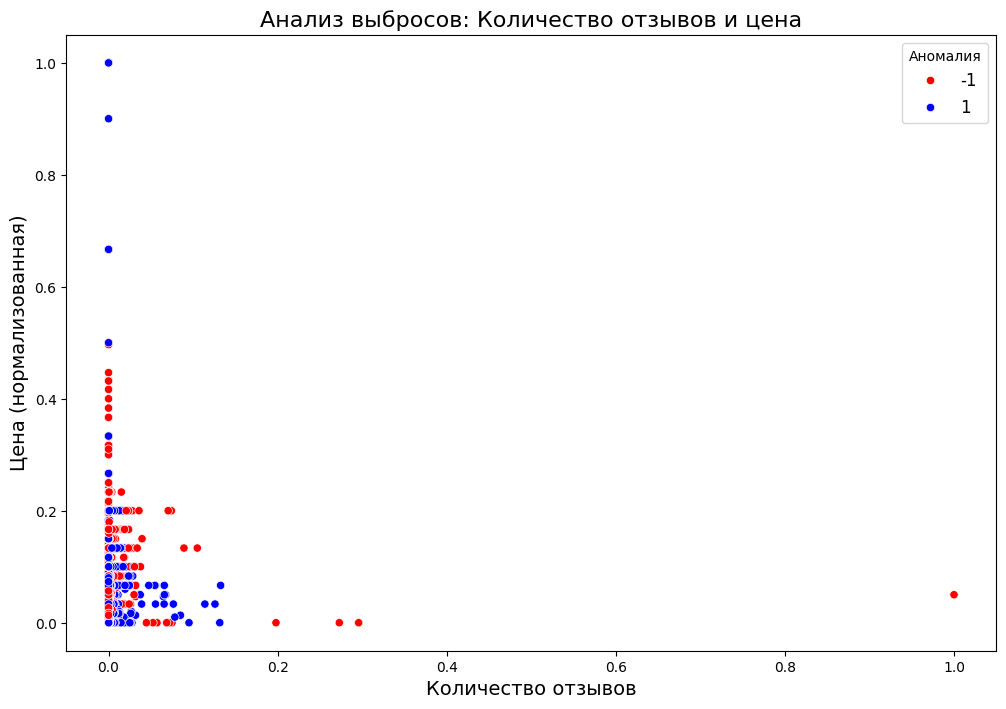

In [ ]:
# Визуализация выбросов (например, отзывов vs. цены)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=preprocessed_data, x='user_reviews', y='price_final', hue='anomaly', palette={1: 'blue', -1: 'red'}
)
plt.title("Анализ выбросов: Количество отзывов и цена", fontsize=16)
plt.xlabel("Количество отзывов", fontsize=14)
plt.ylabel("Цена (нормализованная)", fontsize=14)
plt.legend(title="Аномалия", fontsize=12)
plt.show()


In [ ]:
# Уменьшенная выборка

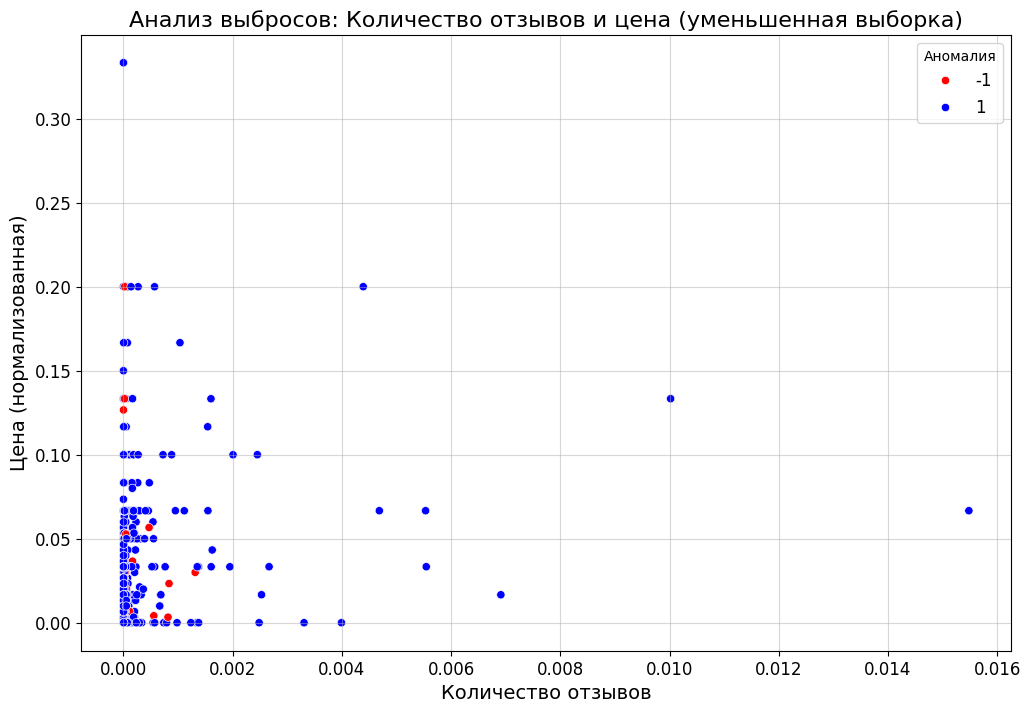

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Выбор случайной подвыборки данных
sample_size = 1000  # Количество записей в выборке
sample_data = preprocessed_data.sample(n=sample_size, random_state=42)  # Выбираем случайную подвыборку

# Визуализация выбросов в уменьшенной выборке
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=sample_data, x='user_reviews', y='price_final', hue='anomaly', palette={1: 'blue', -1: 'red'}
)
plt.title("Анализ выбросов: Количество отзывов и цена (уменьшенная выборка)", fontsize=16)
plt.xlabel("Количество отзывов", fontsize=14)
plt.ylabel("Цена (нормализованная)", fontsize=14)
plt.legend(title="Аномалия", fontsize=12)
plt.grid(alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [ ]:
import pandas as pd

# Загрузка предварительно обработанных данных
file_path = "games_preprocessed.csv"
preprocessed_data = pd.read_csv(file_path)


In [ ]:
# Определяем целевую переменную и признаки
features = ['price_final', 'positive_ratio', 'user_reviews']  # Пример признаков, измените на свои
target = 'rating_encoded'  # Убедитесь, что эта колонка существует

if target in preprocessed_data.columns:
    X = preprocessed_data[features]
    y = preprocessed_data[target]
    print("Переменные X и y успешно созданы.")
else:
    print(f"Целевая переменная '{target}' отсутствует в данных.")


Целевая переменная 'rating_encoded' отсутствует в данных.


In [ ]:
print(preprocessed_data.columns)


Index(['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating',
       'positive_ratio', 'user_reviews', 'price_final', 'price_original',
       'discount', 'steam_deck'],
      dtype='object')


In [ ]:
# Преобразование rating в rating_encoded (числовую целевую переменную)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Кодирование столбца 'rating'
preprocessed_data['rating_encoded'] = LabelEncoder().fit_transform(preprocessed_data['rating'])
print("Целевая переменная 'rating_encoded' успешно создана.")

# Проверим результат кодирования
print(preprocessed_data[['rating', 'rating_encoded']].head())


Целевая переменная 'rating_encoded' успешно создана.
          rating  rating_encoded
0  Very Positive               8
1       Positive               6
2  Very Positive               8
3          Mixed               0
4  Very Positive               8


In [ ]:
# Загрузка данных
file_path = "games_preprocessed.csv"
preprocessed_data = pd.read_csv(file_path)
print("Данные успешно загружены.")
print(preprocessed_data.head())  # Вывод первых нескольких строк для проверки

# Создание признаков и целевой переменной
features = ['price_final', 'positive_ratio', 'user_reviews']
target = 'rating'

if target in preprocessed_data.columns:
    # Кодирование целевой переменной
    preprocessed_data['rating_encoded'] = LabelEncoder().fit_transform(preprocessed_data[target])
    print("Кодирование целевой переменной завершено.")
    print(preprocessed_data[['rating', 'rating_encoded']].head())  # Проверка результата кодирования

    # Создание X и y
    X = preprocessed_data[features]
    y = preprocessed_data['rating_encoded']
    print("Признаки (X) и целевая переменная (y) успешно созданы.")
    print("Примеры данных X:")
    print(X.head())  # Проверка X
    print("Примеры данных y:")
    print(y.head())  # Проверка y
else:
    raise ValueError(f"Целевая переменная '{target}' отсутствует в данных.")


Данные успешно загружены.
     app_id                              title date_release   win    mac  \
0  0.005190  Prince of Persia: Warrior Within™   2008-11-21  True  False   
1  0.008600            BRINK: Agents of Change   2011-08-03  True  False   
2  0.043477       Monaco: What's Yours Is Mine   2013-04-24  True   True   
3  0.087158                 Escape Dead Island   2014-11-18  True  False   
4  0.095811            Dungeon of the ENDLESS™   2014-10-27  True   True   

   linux         rating  positive_ratio  user_reviews  price_final  \
0  False  Very Positive            0.84      0.000292     0.033301   
1  False       Positive            0.85      0.000001     0.009967   
2   True  Very Positive            0.92      0.000495     0.049968   
3  False          Mixed            0.61      0.000115     0.049968   
4  False  Very Positive            0.88      0.001171     0.039968   

   price_original  discount  steam_deck  
0        0.033301       0.0        True  
1        0.0

In [ ]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# 5.Графики ошибок прогнозирования

In [ ]:
# 5.1 Распределение ошибок

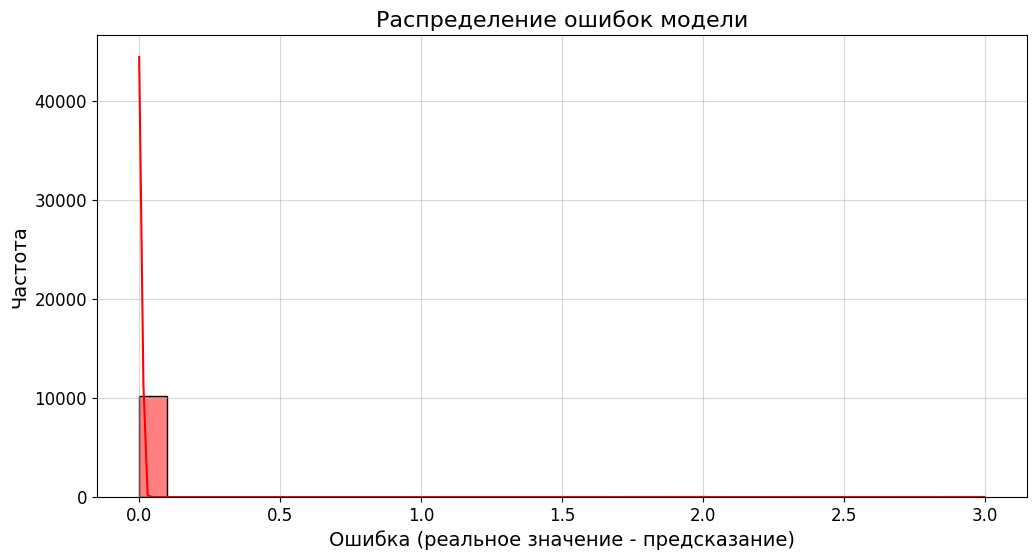

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Вычисление ошибок (реальное значение - предсказание)
errors = y_test - predictions  # predictions — массив предсказаний модели

plt.figure(figsize=(12, 6))
sns.histplot(errors, bins=30, kde=True, color='red')
plt.title("Распределение ошибок модели", fontsize=16)
plt.xlabel("Ошибка (реальное значение - предсказание)", fontsize=14)
plt.ylabel("Частота", fontsize=14)
plt.grid(alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [ ]:
#5.2 Остаточный анализ

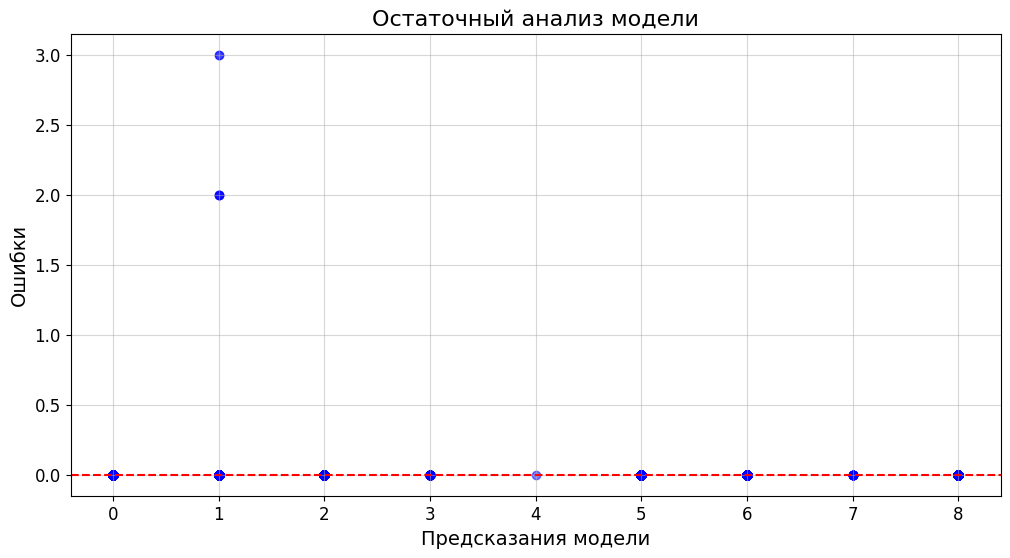

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(predictions, errors, color='blue', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Остаточный анализ модели", fontsize=16)
plt.xlabel("Предсказания модели", fontsize=14)
plt.ylabel("Ошибки", fontsize=14)
plt.grid(alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [ ]:
#6 Графики метрик качества

In [ ]:
# 6.1 ROC-кривая

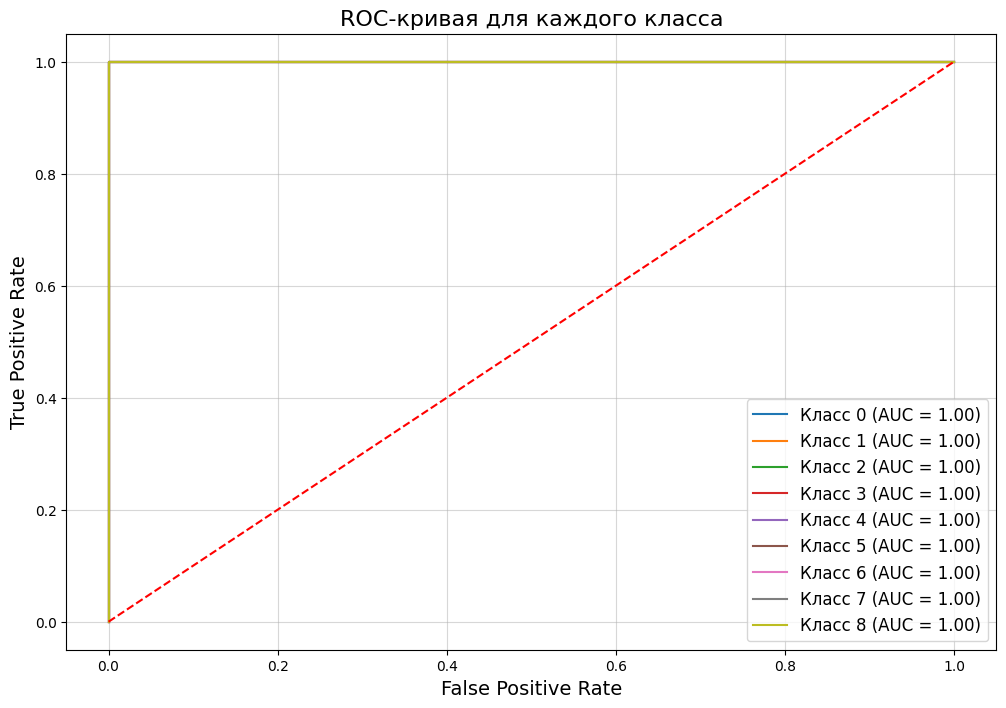

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Визуализация ROC-кривой для каждого класса
plt.figure(figsize=(12, 8))
for i in range(probabilities.shape[1]):  # Количество классов
    y_test_binary = (y_test == i).astype(int)  # Бинарная метка для текущего класса
    probabilities_binary = probabilities[:, i]  # Вероятности для текущего класса

    # Вычисление ROC-кривой и AUC
    fpr, tpr, _ = roc_curve(y_test_binary, probabilities_binary)
    auc_score = roc_auc_score(y_test_binary, probabilities_binary)

    # Добавление кривой на график
    plt.plot(fpr, tpr, label=f"Класс {i} (AUC = {auc_score:.2f})")

# Добавление общей информации
plt.plot([0, 1], [0, 1], 'r--')  # Линия случайного предположения
plt.title("ROC-кривая для каждого класса", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()





In [ ]:
# Важность признаков

<ipython-input-52-2892bbedfbc3>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette='viridis')


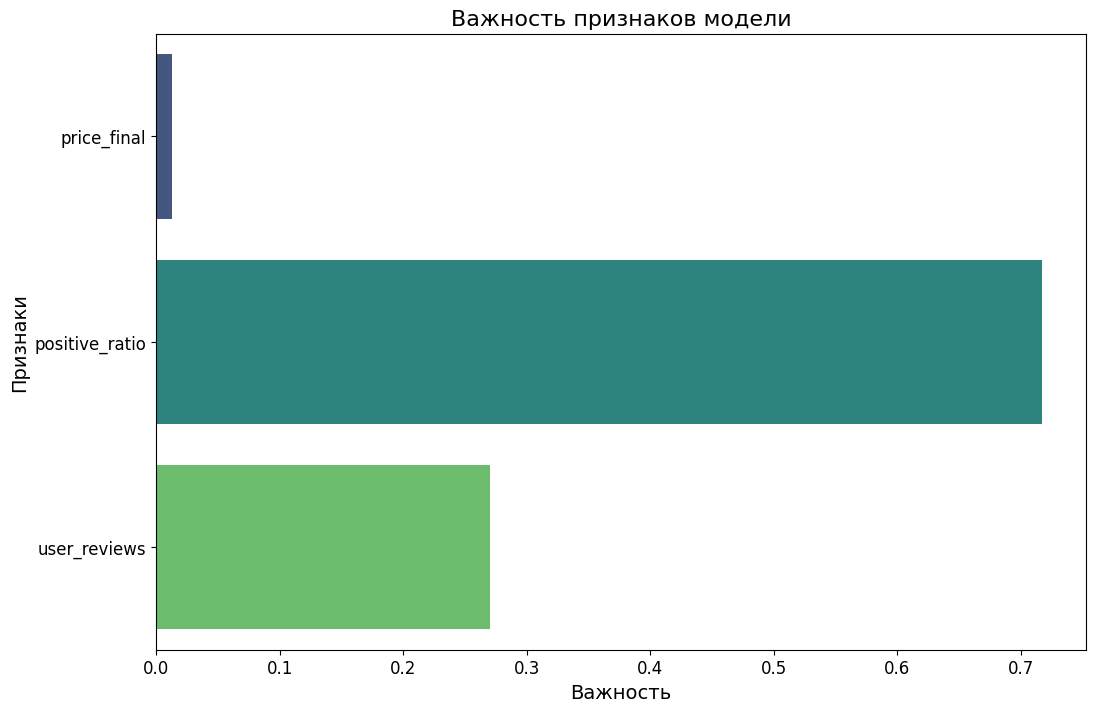

In [ ]:
import seaborn as sns

# Получение важности признаков из обученной модели
importance = model.feature_importances_  # Работает для деревьев решений или случайного леса
features = X_train.columns  # Названия признаков

# Создание графика
plt.figure(figsize=(12, 8))
sns.barplot(x=importance, y=features, palette='viridis')
plt.title("Важность признаков модели", fontsize=16)
plt.xlabel("Важность", fontsize=14)
plt.ylabel("Признаки", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()
